Modified form the example [gantian127/soilgrids](https://github.com/gantian127/soilgrids)  and may check [soilgrids](https://pypi.org/project/soilgrids/) Python Package



```
Citation
Gan, T., Tucker, G.E., Hutton, E.W.H., Piper, M.D., Overeem, I., Kettner, A.J., Campforts, B., Moriarty, J.M., Undzis, B., Pierce, E., McCready, L., 2024: CSDMS Data Components: data–model integration tools for Earth surface processes modeling. Geosci. Model Dev., 17, 2165–2185. https://doi.org/10.5194/gmd-17-2165-2024
```



In [34]:
from google.colab import drive
drive.mount('/content/drive',force_remount = True)
path = '/content/drive/MyDrive/Soil_Data'

In [6]:
! pip install soilgrids

In [39]:
import os
import matplotlib.pyplot as plt
from soilgrids import SoilGrids

In [40]:
# get data from SoilGrids
soil_grids = SoilGrids()
soil_grids.map_services

service id: bdod
variable name: Bulk density
variable units: cg/cm3
service link: https://maps.isric.org/mapserv?map=/map/bdod.map
service id: cec
variable name: Citation exchange capacity at ph7
variable units: mmol(c)/kg
service link: https://maps.isric.org/mapserv?map=/map/cec.map
service id: cfvo
variable name: Coarse fragments volumetric
variable units: cm3/dm3 (vol‰)
service link: https://maps.isric.org/mapserv?map=/map/cfvo.map
service id: clay
variable name: Clay content
variable units: g/kg
service link: https://maps.isric.org/mapserv?map=/map/clay.map
service id: nitrogen
variable name: Nitrogen
variable units: cg/kg
service link: https://maps.isric.org/mapserv?map=/map/nitrogen.map
service id: phh2o
variable name: Soil pH in H2O
variable units: pH*10
service link: https://maps.isric.org/mapserv?map=/map/phh2o.map
service id: sand
variable name: Sand content
variable units: g/kg
service link: https://maps.isric.org/mapserv?map=/map/sand.map
service id: silt
variable name: Sil

In [ ]:
#Define bounding box in EPSG:4326
west, south, east, north = 77.35, 28.70, 81.13, 31.55
xres, yres = 0.0020837927, 0.0020833333   #Here 250m change as per your UTM Zone (ask any LLM)

In [48]:
width = (east - west) / xres
height = (north - south) / yres

def compute_raster_shape(west, south, east, north, xres, yres):
    width = (east - west) / xres
    height = (north - south) / yres
    span_x = east - west
    span_y = north - south
    return int(round(width)), int(round(height)), span_x, span_y
cols, rows, span_x, span_y = compute_raster_shape(west, south, east, north, xres, yres)
print("Columns:", cols, "Rows:", rows)

Columns: 1814 Rows: 1368


```
Service_id = Check from the map_services
```
and
```
Coverage_id = Service_id + "_" + Soil_Depth + "_" + Statistic
```
```
# Statistic
# mean   = Mean
# Q0.5   = Median
# Q0.05  = 5th percentile
# Q0.95  = 95th percentile
# uncertainty
```
```
#Soil_Depth = 0–5cm, 5–15cm,15–30cm, 30–60cm, 60–100cm, 100–200cm
```


variable_name: Soil pH in H2O
variable_units: pH*10
service_url: https://maps.isric.org/mapserv?map=/map/phh2o.map
service_id: phh2o
coverage_id: phh2o_0-5cm_mean
crs: urn:ogc:def:crs:EPSG::4326
bounding_box: (77.35, 28.7, 81.13, 31.55)
grid_res: [0.0020837927232635113, 0.002083333333333336]


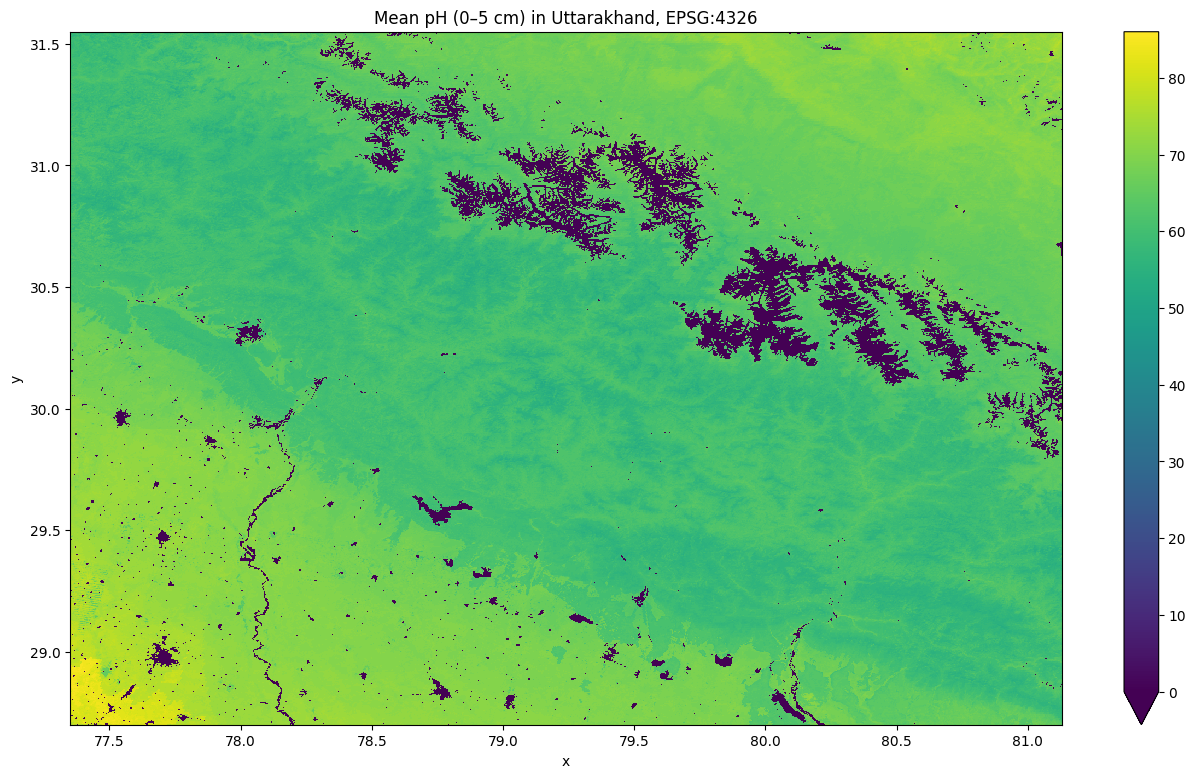

In [55]:
# Request data in EPSG:4326
data = soil_grids.get_coverage_data(
    service_id="phh2o",
    coverage_id="phh2o_0-5cm_mean",
    west=west,
    south=south,
    east=east,
    north=north,
    crs="urn:ogc:def:crs:EPSG::4326",  # WGS84
    width=width,
    height=height,
    output="UK_phh2o.tif",)

# Show metadata
for key, value in soil_grids.metadata.items():
    print(f"{key}: {value}")

# Plot
data.plot(figsize=(16,9), vmin=0)
plt.title("Mean pH (0–5 cm) in Uttarakhand, EPSG:4326")
plt.show()


variable_name: World Reference Base (WRB) classes and probabilities
variable_units: none
service_url: https://maps.isric.org/mapserv?map=/map/wrb.map
service_id: wrb
coverage_id: MostProbable
crs: urn:ogc:def:crs:EPSG::4326
bounding_box: (77.35, 28.7, 81.13, 31.55)
grid_res: [0.0020837927232635113, 0.002083333333333336]


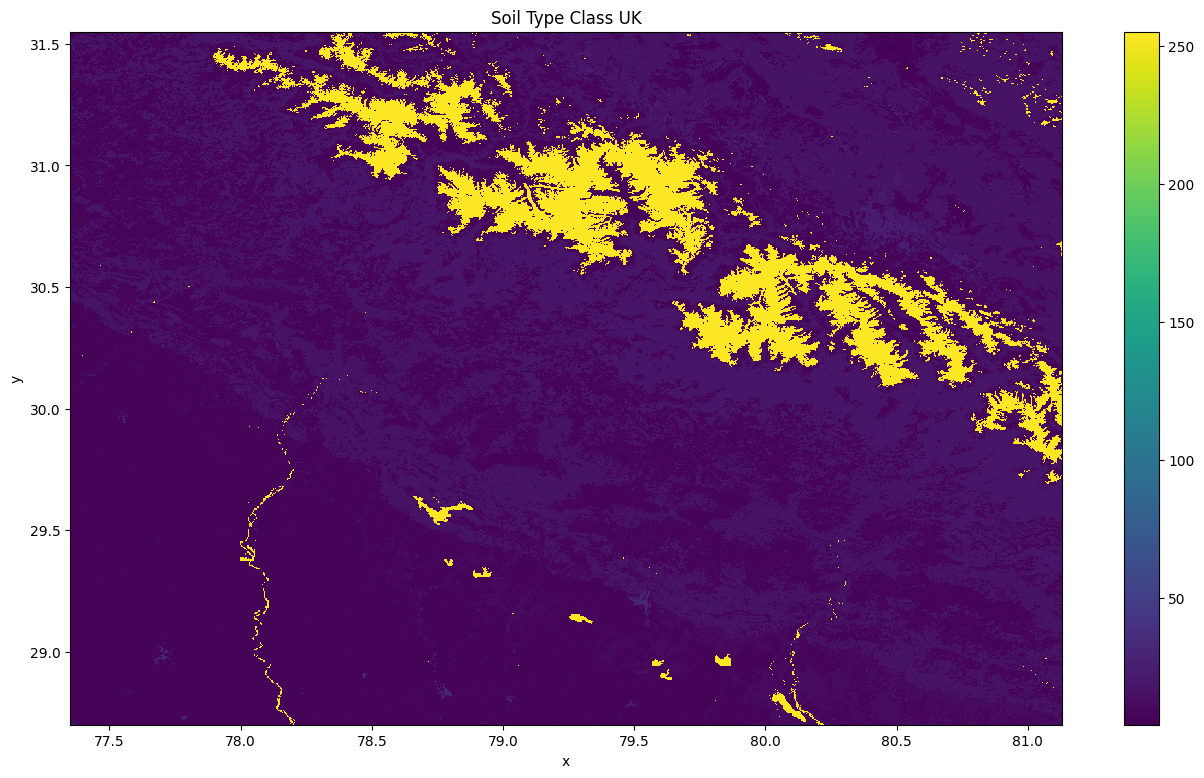

In [51]:
# Request WRB "MostProbable" class map
data = soil_grids.get_coverage_data(
    service_id="wrb",
    coverage_id="MostProbable",   # WRB dominant class per pixel
    west=west,
    south=south,
    east=east,
    north=north,
    crs="urn:ogc:def:crs:EPSG::4326",
    width=width,
    height=height,
    output=os.path.join(path, "UK1.tif"),  # save directly as UK.tif
)

# Show metadata
for key, value in soil_grids.metadata.items():
    print(f"{key}: {value}")

# Plot
data.plot(figsize=(16, 9))
plt.title("Soil Type Class UK")
plt.show()
